In [7]:
import tensorflow as tf
from tensorflow.data import TFRecordDataset 
import numpy as np
import os
import matplotlib.pyplot as plt
from common import fast_gpu_map,SAMPLERATE,feature_description

from model import build_1d_cnn_model
import common


BATCH_SIZE=1
recordfile="/data/test_subset/filtered_poly_data_64956.tfrecord"
model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch25_valAcc0.9679_valPrec0.8958_valRecall0.2594.weights.h5"#
#model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5"

cnn_model=build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE,44,training=False)# common.OUTPUT_DIM_NOTES,training=False)
cnn_model.load_weights(model_weights)
dataset=TFRecordDataset(recordfile)
def parse_example(example_proto):
    return tf.io.parse_single_example(example_proto, feature_description)
# Parse the dataset
dataset = dataset.map(parse_example).shuffle(buffer_size=10000,reshuffle_each_iteration=True)
dataset=dataset.map(lambda x: fast_gpu_map(x,training=False)).batch(BATCH_SIZE,drop_remainder=True).take(1000).prefetch(tf.data.AUTOTUNE)
#dataset=dataset.map(lambda path: fast_gpu_map(path, training=False)).take(100).prefetch(tf.data.AUTOTUNE)
#dataset = dataset.shuffle(BATCH_SIZE * 2).map(lambda path: fast_gpu_map(path, training=False), num_parallel_calls=tf.data.AUTOTUNE)
labels_true_all=[]
labels_pred_all=[]
total_tp=0
total_fp=0
total_fn=0
for audio,label in dataset:
    # print("Audio shape:", audio.shape)
    pred=cnn_model.predict(audio,verbose=0)
    # print("Pred shape:", pred.shape)
    # print("Label shape:", label.shape)
    label=label.numpy()#.flatten()
    pred=pred#.flatten()
    # print("flat Pred shape:", pred.shape)
    # print("flat Label shape:", label.shape)
    labels_true_all.append(label)
    labels_pred_all.append(pred)
    thresh=0.5
    label_active = label#[:88] # Assuming 88 notes
    pred_active = pred#[ :88]
    total_tp += np.sum((label_active == 1) & (pred_active > thresh))
    #total_tp+=np.sum((label==1) & (pred>thresh))
    total_fp+=np.sum((label_active==0)&(pred_active>thresh))
    total_fn+=np.sum((label_active==1)&(pred_active<=thresh))

print("Total True Positives:", total_tp)
print("Total False Positives:", total_fp)
print("Total False Negatives:", total_fn)
precision=total_tp/(total_tp+total_fp+1e-8)
recall=total_tp/(total_tp+total_fn+1e-8)
print("Precision:", precision)
print("Recall:", recall)


Before string split: (1, 74, 64), max_x=74.0
  String slice [0:26]
  String slice [10:36]
  String slice [20:46]
  String slice [30:56]
  String slice [38:64]
  String slice [48:73]


I0000 00:00:1774335058.986883  369405 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122362__.23


Total True Positives: 779
Total False Positives: 78
Total False Negatives: 2791
Precision: 0.9089848307945276
Recall: 0.21820728291255403


In [8]:
print("Length of labels_true_all:", len(labels_true_all))
labels_true=np.concatenate(labels_true_all,axis=0)
labels_pred=np.concatenate(labels_pred_all,axis=0)
labels_pred=(labels_pred>0.5).astype(np.float32)
print("Shape of labels true:",labels_true.shape)
#compute recall
tp=np.sum((labels_true==1) & (labels_pred==1),axis=0)

fp=np.sum((labels_true==0)&(labels_pred==1),axis=0)
fn=np.sum((labels_true==1)&(labels_pred==0),axis=0)
print("Shape of tp",tp.shape)

precision=tp/(tp+fp+1e-8)
print("precision:", precision)
recall=tp/(tp+fn+1e-8)
print("recall:", recall)
print("True Positives:", tp)
print("False Positives:", fp)

Length of labels_true_all: 1000
Shape of labels true: (1000, 44)
Shape of tp (44,)
precision: [0.97058824 0.99999999 0.9375     1.         1.         0.72222222
 0.9047619  0.75       0.96721311 0.66666667 0.96629213 0.78571429
 0.95454545 0.72222222 0.62068965 0.89873418 1.         0.89130435
 0.9        0.9375     1.         0.         0.97590361 0.
 1.         0.         0.         0.91428571 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
recall: [0.23913043 0.02272727 0.57692308 0.31132075 0.55       0.1969697
 0.296875   0.06060606 0.33146067 0.17391304 0.2721519  0.78571429
 0.24418605 0.07471264 0.16666667 0.568      0.23809524 0.17672414
 0.06923077 0.10416667 0.3028169  0.         0.35840708 0.
 0.1375     0.         0.         0.37209302 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 

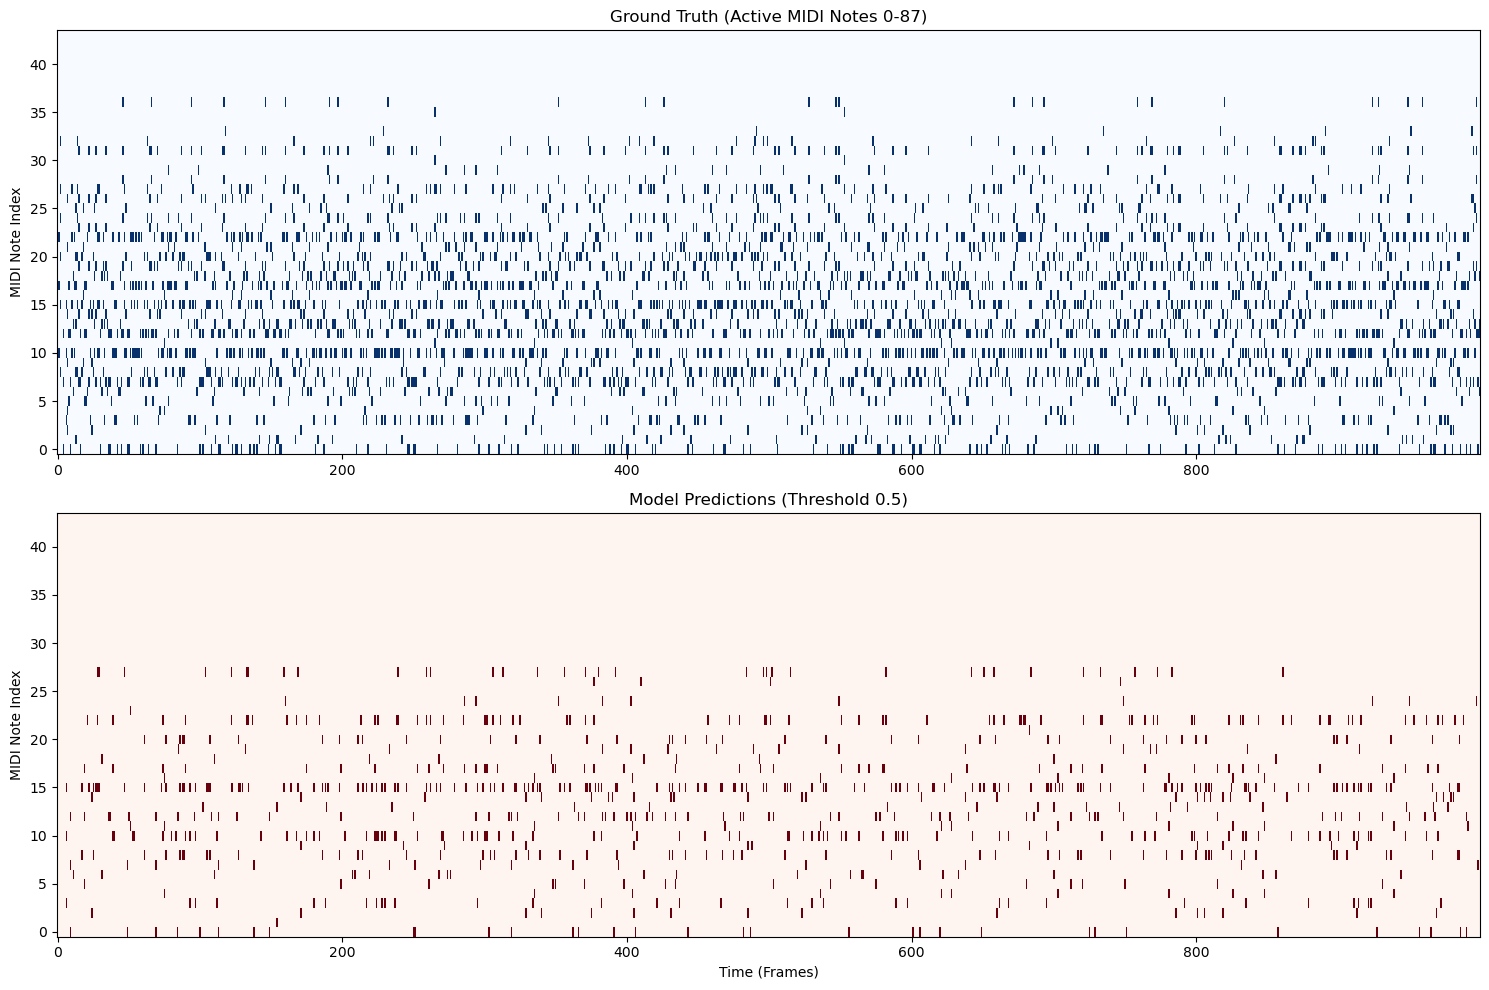

In [9]:
# Convert lists to single arrays
all_true = np.concatenate(labels_true_all, axis=0)[:, :88]
all_pred = np.concatenate(labels_pred_all, axis=0)[:, :88]

# Binary threshold for the plot
all_pred_bin = (all_pred > 0.5).astype(np.float32)

plt.figure(figsize=(15, 10))

# Plot Ground Truth (Blue)
plt.subplot(2, 1, 1)
plt.imshow(all_true.T, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
plt.title("Ground Truth (Active MIDI Notes 0-87)")
plt.ylabel("MIDI Note Index")

# Plot Predictions (Red)
plt.subplot(2, 1, 2)
plt.imshow(all_pred_bin.T, aspect='auto', origin='lower', cmap='Reds', interpolation='nearest')
plt.title("Model Predictions (Threshold 0.5)")
plt.ylabel("MIDI Note Index")
plt.xlabel("Time (Frames)")

plt.tight_layout()
plt.show()